No outliers in L5 to L5
Sample size: 100
Found outliers in L2/3 to L5:
      pregid  postgid  frequency_train  dt_train  epsp_ratio  epsp_before
54    114115   137449             50.0        50   15.987110     0.002918
154   114115   137449             50.0        30   13.218986     0.003736
254   114115   137449             50.0        10   82.681035     0.000663
354   114115   137449             50.0       -10   14.349744     0.002619
454   114115   137449             50.0       -30   16.869679     0.002621
554   114115   137449             50.0       -50   11.998958     0.004224
654   114115   137449             20.0        50   30.279058     0.001968
754   114115   137449             20.0        30   38.184890     0.001468
854   114115   137449             20.0        10    8.548790     0.004734
954   114115   137449             20.0       -10   15.075614     0.002627
1054  114115   137449             20.0       -30   37.098071     0.001467
1154  114115   137449             20.0   

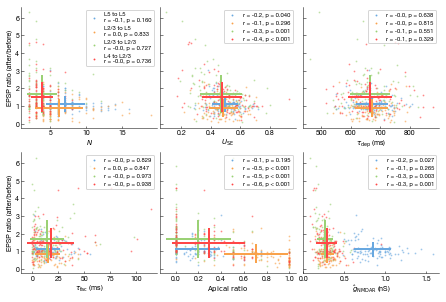

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib import colors

# Configure matplotlib
plt.style.use('onerule.mplstyle')

x_vars = [('N', r'$N$'),
          ('Use_before_mean', r'$U_\mathrm{SE}$'),
          ('Dep_mean', r'$\tau_\mathrm{dep}$ (ms)'),
          ('Fac_mean', r'$\tau_\mathrm{fac}$ (ms)'),
          ('apical_ratio', r'$\mathrm{Apical} \; \mathrm{ratio}$'),
          ('gmax_NMDA_before_mean', r'$\^g_\mathrm{NMDAR}$ (nS)')]

freq, dt = 10, 10

experiments = [('L5 to L5', 0.55, 'data/insilico/markram_1997/L5TTPC_L5TTPC.csv'),
               ('L2/3 to L5', 0.4, 'data/insilico/stdp_2021/L23PC_L5TTPC.csv'),
               ('L2/3 to L2/3', 0.4, 'data/insilico/stdp_2021/L23PC_L23PC.csv'),
               ('L4 to L2/3', 0.4, 'data/insilico/stdp_2021/L4PC_L23PC.csv')]

fig, axarr = plt.subplots(2, 3, sharey=True, figsize=(6, 4))

for conn_label, nmda_ratio, conn_type in experiments:
    data = pd.read_csv(conn_type)
    data['gmax_NMDA_before_mean'] = data['gmax_AMPA_before_mean'] * nmda_ratio
    outliers = data[data.epsp_before<0.01]
    if outliers.shape[0] > 0:
        print('Found outliers in %s:' % (conn_label,))
        print(outliers[['pregid', 'postgid', 'frequency_train', 'dt_train', 'epsp_ratio', 'epsp_before']])
    else:
        print('No outliers in %s' % (conn_label,))
    df = data.drop(outliers.index)
    sample = df[(df.frequency_train == freq) & (df.dt_train == dt)]
    print("Sample size: %d" % sample.shape[0])
    
    for j, (x_var, x_label) in enumerate(x_vars):
        ax = axarr[j//3][j%3]

        corr, pval = stats.spearmanr(sample[x_var], sample.epsp_ratio)
        pval_str = "p = %.3f" % pval if pval >= 0.001 else "p < 0.001"
        label = "%s\nr = %.1f, %s" % (conn_label, corr, pval_str) if j == 0 else "r = %.1f, %s" % (corr, pval_str)

        ax.scatter(sample[x_var], sample.epsp_ratio, s=3, marker='.', alpha=.5,
                   label=label)

        ax.errorbar(sample[x_var].mean(), sample.epsp_ratio.mean(),
                    xerr=sample[x_var].std(), yerr=sample.epsp_ratio.std(),
                    lw=2)
        
        if j % 3 == 0:
            ax.set_ylabel("EPSP ratio (after/before)")
        
        leg = ax.legend(loc=1, frameon=True)
        for lh in leg.legendHandles: 
            lh.set_alpha(1)
    
        ax.set_xlabel(x_label)

#fig.savefig('params_vs_epsp_matrix.svg')
#fig.savefig('params_vs_epsp_matrix.png', dpi=300, bbox_inches='tight')

Iso-levels: [0.3 0.5 0.7 0.9]
No outliers in L5 to L5
Sample size: 100
Found outliers in L2/3 to L5:
      pregid  postgid  frequency_train  dt_train  epsp_ratio  epsp_before
54    114115   137449             50.0        50   15.987110     0.002918
154   114115   137449             50.0        30   13.218986     0.003736
254   114115   137449             50.0        10   82.681035     0.000663
354   114115   137449             50.0       -10   14.349744     0.002619
454   114115   137449             50.0       -30   16.869679     0.002621
554   114115   137449             50.0       -50   11.998958     0.004224
654   114115   137449             20.0        50   30.279058     0.001968
754   114115   137449             20.0        30   38.184890     0.001468
854   114115   137449             20.0        10    8.548790     0.004734
954   114115   137449             20.0       -10   15.075614     0.002627
1054  114115   137449             20.0       -30   37.098071     0.001467
1154  11411

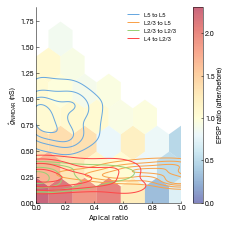

In [2]:
x_var = "apical_ratio"
y_var = "gmax_NMDA_before_mean"
levels = np.linspace(0.3, 0.9, 4)
print("Iso-levels:", levels)

fig, ax = plt.subplots(figsize=(3,3))

x = []
y = []
c = []
for conn_label, nmda_ratio, conn_type in experiments:
    data = pd.read_csv(conn_type)
    data['gmax_NMDA_before_mean'] = data['gmax_AMPA_before_mean'] * nmda_ratio
    outliers = data[data.epsp_before<0.01]
    if outliers.shape[0] > 0:
        print('Found outliers in %s:' % (conn_label,))
        print(outliers[['pregid', 'postgid', 'frequency_train', 'dt_train', 'epsp_ratio', 'epsp_before']])
    else:
        print('No outliers in %s' % (conn_label,))
    df = data.drop(outliers.index)
    sample = df[(df.frequency_train == freq) & (df.dt_train == dt)]
    print("Sample size: %d" % sample.shape[0])

    sns.kdeplot(x=sample[x_var], y=sample[y_var], cut=3,
                linewidths=1, levels=levels,
                ax=ax, label=conn_label)

    x.extend(sample[x_var])
    y.extend(sample[y_var])
    c.extend(sample.epsp_ratio)

divnorm = colors.TwoSlopeNorm(vmin=0, vcenter=1)
sc = ax.hexbin(x, y, C=c, gridsize=6, cmap='RdYlBu_r', norm=divnorm, alpha=.6, edgecolors=None)
plt.colorbar(sc, label='EPSP ratio (after/before)', ax=ax)

ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, None)
ax.set_xlabel(r'$\mathrm{Apical} \; \mathrm{ratio}$')
ax.set_ylabel(r'$\^g_\mathrm{NMDAR}$ (nS)');

#fig.savefig('params_vs_epsp_hexbin.svg')
#fig.savefig('params_vs_epsp_hexbin.png', dpi=300, bbox_inches='tight')